# Decision Tree Pruning: Pre-pruning vs. Post-pruning

This notebook demonstrates the concepts of pre-pruning and post-pruning in decision tree classifiers. We will use the Iris dataset from `sklearn` for this purpose.

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Preparation

First, we'll load the Iris dataset and split it into training and testing sets.

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (105, 4)
Testing data shape: (45, 4)


## 2. Unpruned Decision Tree

Let's train a decision tree without any pruning parameters to see a fully grown (and potentially overfitted) tree.

Accuracy of unpruned tree: 1.0000


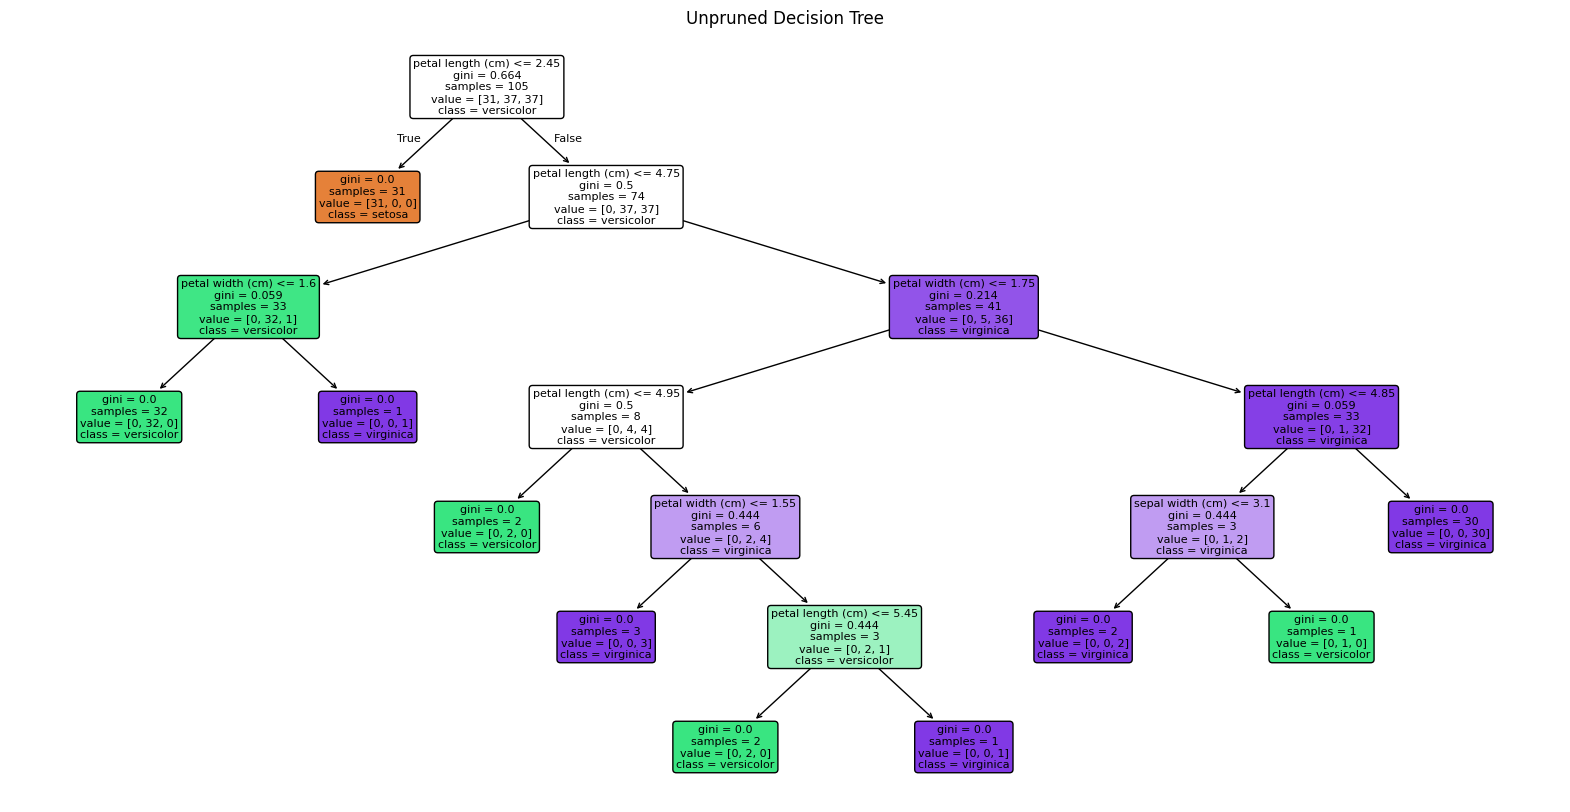

In [3]:
# Train an unpruned Decision Tree Classifier
unpruned_dt = DecisionTreeClassifier(random_state=42)
unpruned_dt.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_unpruned = unpruned_dt.predict(X_test)
accuracy_unpruned = accuracy_score(y_test, y_pred_unpruned)
print(f"Accuracy of unpruned tree: {accuracy_unpruned:.4f}")

# Visualize the unpruned tree (optional, as it might be very large)
plt.figure(figsize=(20, 10))
plot_tree(unpruned_dt, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True, fontsize=8)
plt.title("Unpruned Decision Tree")
plt.show()

## 3. Pre-pruning

Pre-pruning involves stopping the tree's growth early during training. This is typically done by setting hyperparameters like `max_depth`, `min_samples_leaf`, or `min_samples_split` before the tree is built.

Let's demonstrate pre-pruning using `max_depth`.

Accuracy of pre-pruned tree (max_depth=3): 1.0000


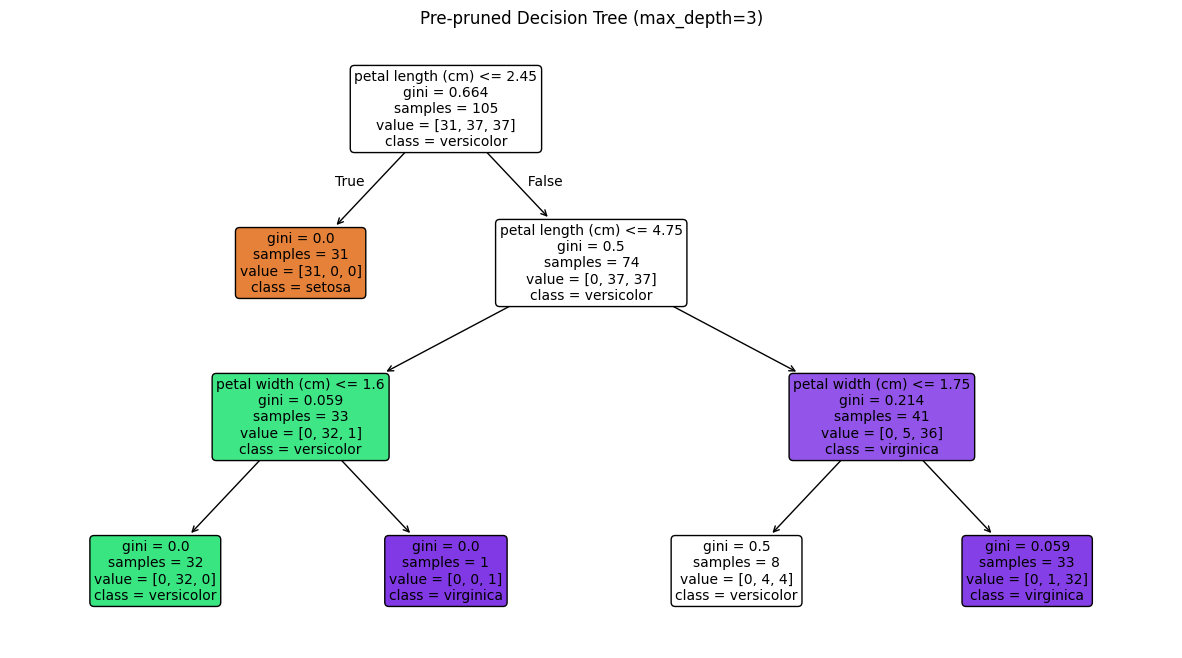

In [4]:
# Pre-pruning with max_depth=3
prepruned_dt_max_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
prepruned_dt_max_depth.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_prepruned_max_depth = prepruned_dt_max_depth.predict(X_test)
accuracy_prepruned_max_depth = accuracy_score(y_test, y_pred_prepruned_max_depth)
print(f"Accuracy of pre-pruned tree (max_depth=3): {accuracy_prepruned_max_depth:.4f}")

# Visualize the pre-pruned tree
plt.figure(figsize=(15, 8))
plot_tree(prepruned_dt_max_depth, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True, fontsize=10)
plt.title("Pre-pruned Decision Tree (max_depth=3)")
plt.show()

Accuracy of pre-pruned tree (min_samples_leaf=5): 1.0000


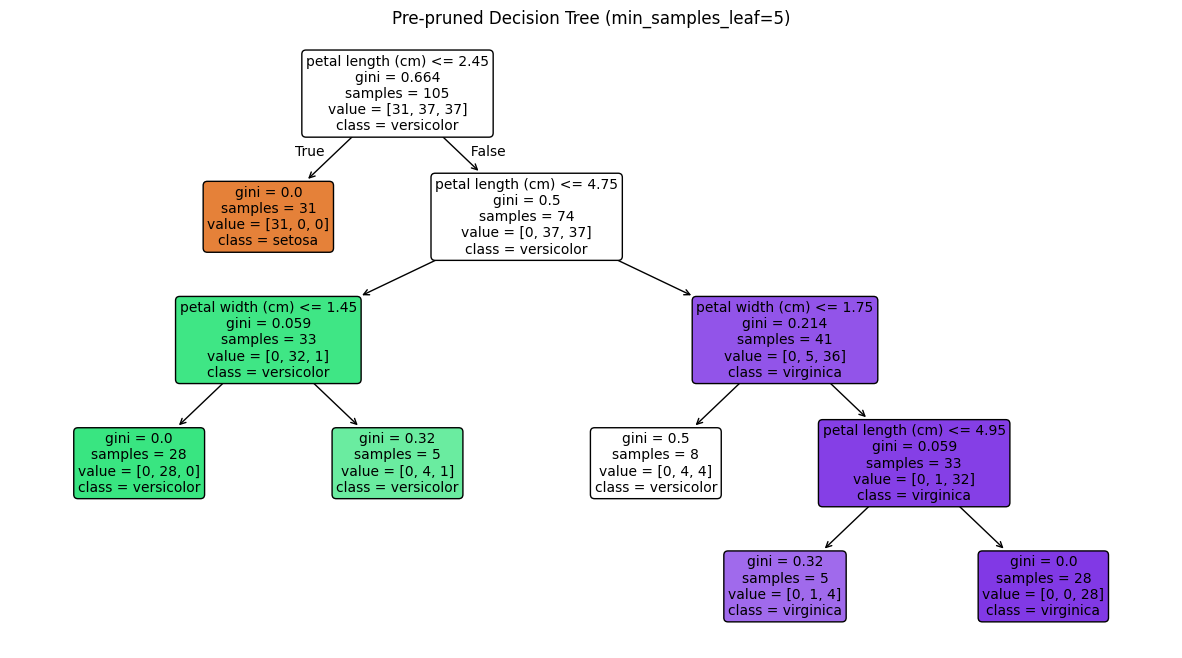

In [5]:
# Pre-pruning with min_samples_leaf=5
prepruned_dt_min_samples = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
prepruned_dt_min_samples.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_prepruned_min_samples = prepruned_dt_min_samples.predict(X_test)
accuracy_prepruned_min_samples = accuracy_score(y_test, y_pred_prepruned_min_samples)
print(f"Accuracy of pre-pruned tree (min_samples_leaf=5): {accuracy_prepruned_min_samples:.4f}")

# Visualize the pre-pruned tree
plt.figure(figsize=(15, 8))
plot_tree(prepruned_dt_min_samples, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True, fontsize=10)
plt.title("Pre-pruned Decision Tree (min_samples_leaf=5)")
plt.show()

## 4. Post-pruning (Cost Complexity Pruning)

Post-pruning involves growing a full decision tree first and then removing (pruning) branches that do not contribute significantly to the predictive accuracy. `sklearn` implements this using **cost complexity pruning** (also known as weakest link pruning or error complexity pruning).

This method finds the optimal subtree by minimizing a cost function that considers both the error rate and the complexity of the tree (number of leaves), controlled by a parameter `ccp_alpha`.

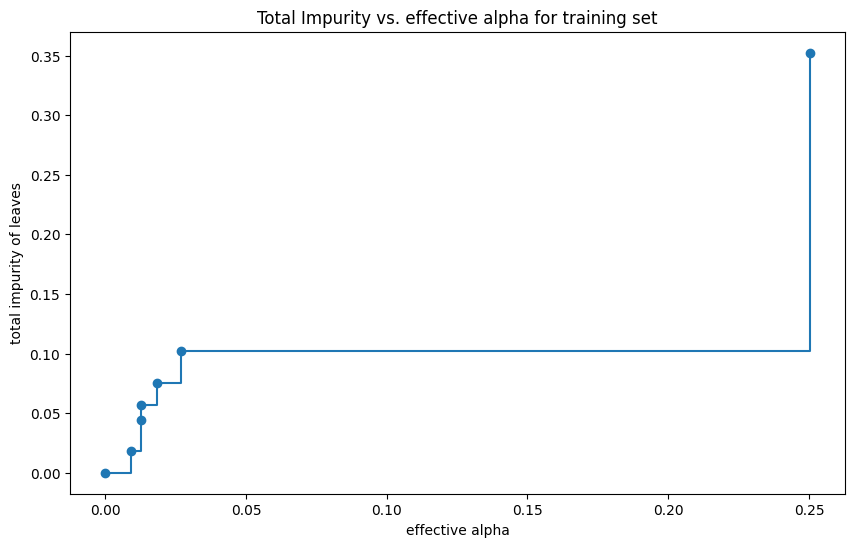

In [6]:
# Train a full decision tree first (this will be the basis for post-pruning)
full_dt = DecisionTreeClassifier(random_state=42)
full_dt.fit(X_train, y_train)

# Calculate the effective alphas and corresponding impurities
path = full_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Plot the impurities vs. effective alpha values
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs. effective alpha for training set")
plt.show()

The `ccp_alphas` represent the complexity parameters. A higher `ccp_alpha` leads to more pruning (a smaller tree).

Now, we will train a series of trees with different `ccp_alpha` values and evaluate their performance on the test set to find the optimal `alpha`.

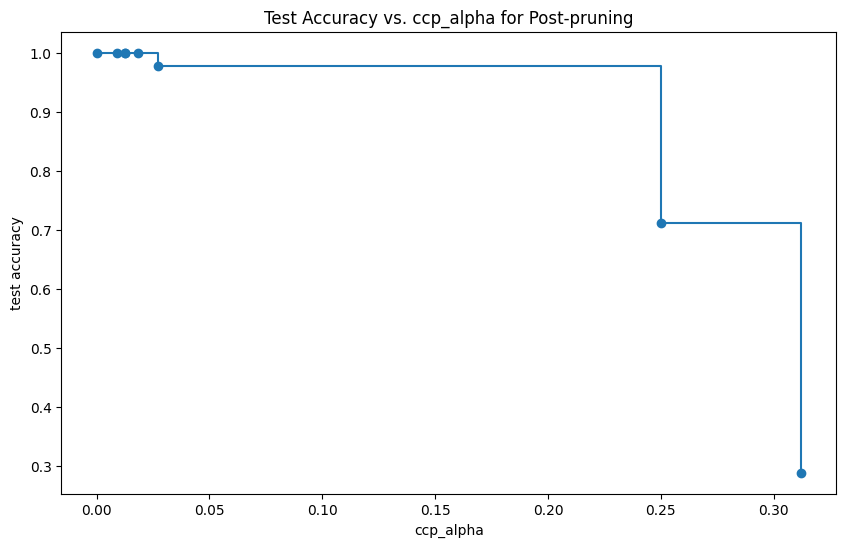

Optimal ccp_alpha: 0.0000
Maximum test accuracy with optimal ccp_alpha: 1.0000


In [7]:
dts = []
accuracies = []

for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    dts.append(dt)
    y_pred = dt.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs. ccp_alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, accuracies, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("test accuracy")
plt.title("Test Accuracy vs. ccp_alpha for Post-pruning")
plt.show()

# Find the ccp_alpha that gives the maximum accuracy
optimal_alpha_index = np.argmax(accuracies)
optimal_ccp_alpha = ccp_alphas[optimal_alpha_index]

print(f"Optimal ccp_alpha: {optimal_ccp_alpha:.4f}")
print(f"Maximum test accuracy with optimal ccp_alpha: {accuracies[optimal_alpha_index]:.4f}")

Accuracy of post-pruned tree (optimal ccp_alpha): 1.0000


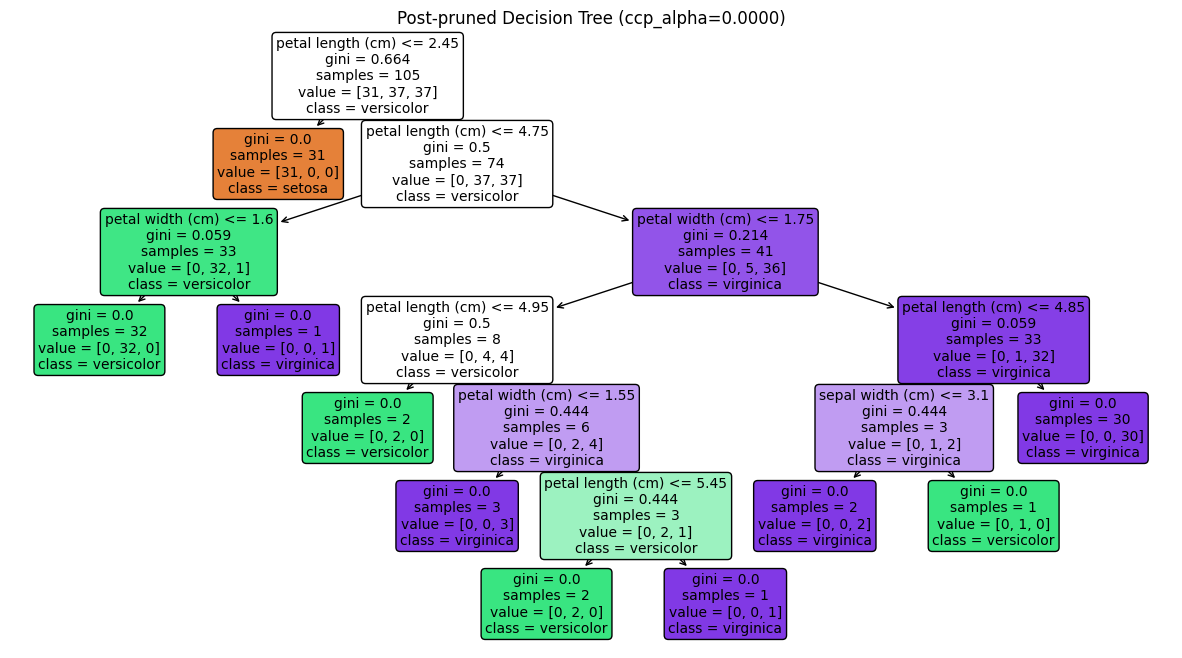

In [8]:
# Train the final post-pruned tree with the optimal ccp_alpha
postpruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
postpruned_dt.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_postpruned = postpruned_dt.predict(X_test)
accuracy_postpruned = accuracy_score(y_test, y_pred_postpruned)
print(f"Accuracy of post-pruned tree (optimal ccp_alpha): {accuracy_postpruned:.4f}")

# Visualize the post-pruned tree
plt.figure(figsize=(15, 8))
plot_tree(postpruned_dt, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True, fontsize=10)
plt.title(f"Post-pruned Decision Tree (ccp_alpha={optimal_ccp_alpha:.4f})")
plt.show()

## 6. Summary and Comparison

Let's compare the performance and complexity of the different trees.

In [9]:
print(f"Accuracy of Unpruned Tree: {accuracy_unpruned:.4f}")
print(f"Number of leaves in Unpruned Tree: {unpruned_dt.get_n_leaves()}\n")

print(f"Accuracy of Pre-pruned Tree (max_depth=3): {accuracy_prepruned_max_depth:.4f}")
print(f"Number of leaves in Pre-pruned Tree (max_depth=3): {prepruned_dt_max_depth.get_n_leaves()}\n")

print(f"Accuracy of Pre-pruned Tree (min_samples_leaf=5): {accuracy_prepruned_min_samples:.4f}")
print(f"Number of leaves in Pre-pruned Tree (min_samples_leaf=5): {prepruned_dt_min_samples.get_n_leaves()}\n")

print(f"Accuracy of Post-pruned Tree (optimal ccp_alpha): {accuracy_postpruned:.4f}")
print(f"Number of leaves in Post-pruned Tree (optimal ccp_alpha): {postpruned_dt.get_n_leaves()}")

Accuracy of Unpruned Tree: 1.0000
Number of leaves in Unpruned Tree: 10

Accuracy of Pre-pruned Tree (max_depth=3): 1.0000
Number of leaves in Pre-pruned Tree (max_depth=3): 5

Accuracy of Pre-pruned Tree (min_samples_leaf=5): 1.0000
Number of leaves in Pre-pruned Tree (min_samples_leaf=5): 6

Accuracy of Post-pruned Tree (optimal ccp_alpha): 1.0000
Number of leaves in Post-pruned Tree (optimal ccp_alpha): 10


As you can see, both pre-pruning and post-pruning help in reducing the complexity of the decision tree, potentially leading to better generalization on unseen data (higher test accuracy) by preventing overfitting. The choice between pre-pruning and post-pruning often depends on the dataset and problem, but post-pruning (specifically `cost_complexity_pruning`) can sometimes lead to more optimal trees as it explores the full tree structure first.